# Bank-Marketing

# 1. Importing libraries

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# 2. EDA – Exploratory data analysis

## Reading the data

In [40]:
data = pd.read_csv(r"Bank-Marketing.txt", sep=';')

In [41]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [42]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [44]:
# of records & features
print("# of records : ",data.shape[0])
print("# of features : ", data.shape[1])

# of records :  41188
# of features :  21


`we have 41188 record and 21 feature and we don't have any null values`

## data cleaning and analysis

`now lets see if we have any duplicated values and remove them`

In [45]:
data.duplicated().sum() # 12 value
data.drop_duplicates(inplace=True)
data.duplicated().any()

np.False_

`we removed 12 records `

### see if we have balanced data

In [46]:
data['y'].value_counts(normalize=True)

y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64

we clearly see the the data is imbalanced `89% no` and `11% yes`

### Remove and fix Leakage Feature

- pdays = number of days since client was last contacted in previous campaign
- Value 999 → client was never contacted before.
- Never contacted → pdays = 999
- Contacted before → actual number of days

In [47]:
data['pdays_days'] = data['pdays'].replace(999, 0)
data = data.drop(columns=['pdays'])

In [48]:
# Select only object (categorical) columns
cat_cols = data.select_dtypes(include=['object']).columns

# Create mask for rows that contain 'unknown' in any categorical column
rows_with_unknown = data[cat_cols].eq('unknown').any(axis=1)

# Drop those rows
data = data.loc[~rows_with_unknown].copy()

# Reset index
data.reset_index(drop=True, inplace=True)

print("Remaining rows:", data.shape[0])

Remaining rows: 30478


### Encode target values

In [49]:
data['y'] = data['y'].map({'yes':1, 'no':0})

### Check for Correlation

In [50]:
corr = data.corr(numeric_only=True)
corr['y'].sort_values(ascending=False)
abs(corr['y']).sort_values(ascending=False)

y                 1.000000
duration          0.393560
nr.employed       0.364230
euribor3m         0.315842
emp.var.rate      0.305320
pdays_days        0.270281
previous          0.228030
cons.price.idx    0.128657
campaign          0.069200
cons.conf.idx     0.061543
age               0.048700
Name: y, dtype: float64

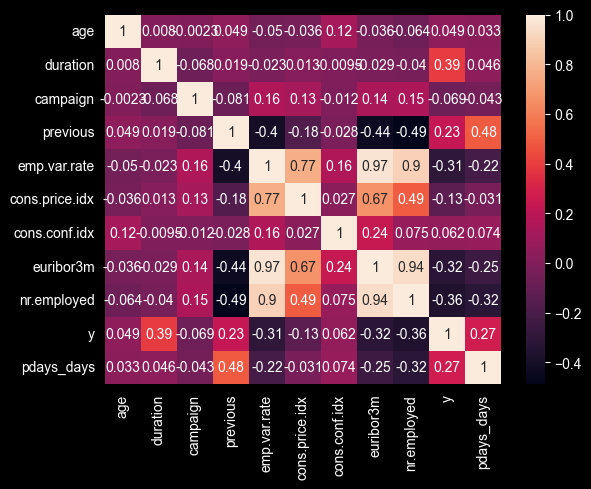

In [51]:
sns.heatmap(corr, annot=True)
plt.show()

 - we clearly see that we **dont** have any strong linear relationship between `y` and other features

### Detect Multicollinearity
- if 2 features have very high corr this mean they almost carry the same information
- Keep only one and drop others

In [52]:
print(corr['emp.var.rate']['euribor3m']) # 0.97
print(corr['euribor3m']["nr.employed"]) # 0.94
print(corr['emp.var.rate']["nr.employed"]) # 0.90

0.9694110589328776
0.9448628317615742
0.9003666894833994


In [53]:
data = data.drop(columns=['euribor3m', 'emp.var.rate'])

## Feature Engineering

In [54]:
data['contact_rate'] = data['previous'] / (data['campaign'] + 1)  # +1 to avoid zero division

In [55]:
data['total_contacts'] = data['campaign'] + data['previous']

In [56]:
spring = ['mar', 'apr', 'may']
summer = ['jun', 'jul', 'aug']
autumn = ['sep', 'oct', 'nov']
winter = ['dec', 'jan', 'feb']

def month_to_season(month):
    if month in spring: return 'spring'
    elif month in summer: return 'summer'
    elif month in autumn: return 'autumn'
    else: return 'winter'

data['season'] = data['month'].apply(month_to_season)

In [57]:
bins_age = [17, 32, 47, 70, 100]
labels_age = [0, 1, 2, 3]
data['age_bin'] = pd.cut(data['age'], bins=bins_age, labels=labels_age)

### Encode Categorical Features
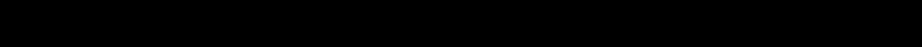
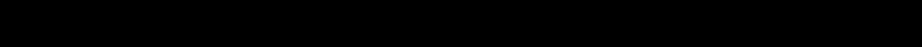

In [58]:
print(data['education'].unique())

['basic.4y' 'high.school' 'basic.6y' 'professional.course' 'basic.9y'
 'university.degree' 'illiterate']


In [59]:
data['education'] = data['education'].map({'unknown':0,'illiterate':1,'basic.4y':2,'basic.6y':3, 'basic.9y':4, 'high.school':5, "university.degree":6,  "professional.course":7})
data["default"] = data["default"].map({'no':0,'yes':1,'unknown':2})
data["housing"] = data["housing"].map({'no':0,'yes':1})
data["loan"] = data["loan"].map({'no':0,'yes':1})

In [60]:
# Label encode nominal columns temporarily
categorical_cols = ['job','marital','education','contact','month','day_of_week','poutcome','season','age_bin']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

In [61]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,cons.price.idx,cons.conf.idx,nr.employed,y,pdays_days,contact_rate,total_contacts,season,age_bin
0,56,3,1,1,0,0,0,1,6,1,...,1,93.994,-36.4,5191.0,0,0,0.00,1,1,2
1,37,7,1,4,0,1,0,1,6,1,...,1,93.994,-36.4,5191.0,0,0,0.00,1,1,1
2,40,0,1,2,0,0,0,1,6,1,...,1,93.994,-36.4,5191.0,0,0,0.00,1,1,1
3,56,7,1,4,0,0,1,1,6,1,...,1,93.994,-36.4,5191.0,0,0,0.00,1,1,2
4,59,0,1,6,0,0,0,1,6,1,...,1,93.994,-36.4,5191.0,0,0,0.00,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,73,5,1,6,0,1,0,0,7,0,...,1,94.767,-50.8,4963.6,1,0,0.00,1,0,3
30474,46,1,1,6,0,0,0,0,7,0,...,1,94.767,-50.8,4963.6,0,0,0.00,1,0,1
30475,56,5,1,5,0,1,0,0,7,0,...,1,94.767,-50.8,4963.6,0,0,0.00,2,0,2
30476,44,9,1,6,0,0,0,0,7,0,...,1,94.767,-50.8,4963.6,1,0,0.00,1,0,1


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30478 non-null  int64  
 1   job             30478 non-null  int64  
 2   marital         30478 non-null  int64  
 3   education       30478 non-null  int64  
 4   default         30478 non-null  int64  
 5   housing         30478 non-null  int64  
 6   loan            30478 non-null  int64  
 7   contact         30478 non-null  int64  
 8   month           30478 non-null  int64  
 9   day_of_week     30478 non-null  int64  
 10  duration        30478 non-null  int64  
 11  campaign        30478 non-null  int64  
 12  previous        30478 non-null  int64  
 13  poutcome        30478 non-null  int64  
 14  cons.price.idx  30478 non-null  float64
 15  cons.conf.idx   30478 non-null  float64
 16  nr.employed     30478 non-null  float64
 17  y               30478 non-null 

### Train Random Forest

In [63]:
# Split features and target
X = data.drop('y', axis=1)
y = data['y']

In [64]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
importances = rf.feature_importances_
feature_names = X.columns
# Create a sorted pandas Series
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

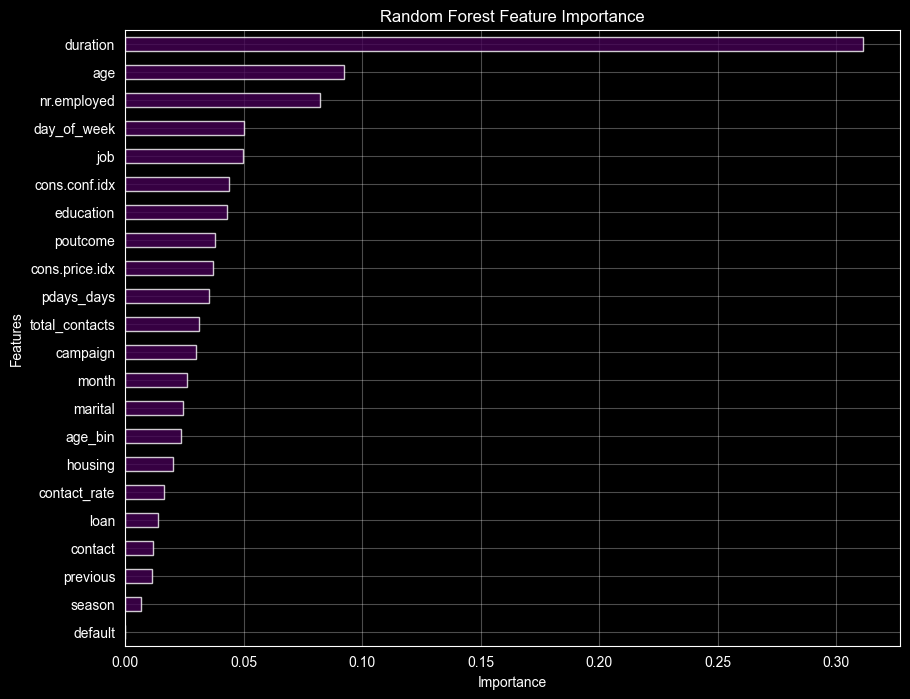

In [66]:
plt.figure(figsize=(10,8))
feat_importance.plot(kind='barh', alpha=0.8, figsize=(10,8), colormap='viridis')
plt.title("Random Forest Feature Importance")
plt.grid(True, alpha=0.3)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [67]:
data.dropna(inplace=True)

# Training Models
we will choose different models
- logistic regression
- Random Forest
- svm
- Gradient boost
- XGbosst

## Data Splitting

In [68]:
X = data.drop(['y',"default"], axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Data Sclaing


In [69]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', C=1, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 1],
        'colsample_bytree': [0.7, 1]
    }
}

class_results = {}
for name, clf in models.items():

    print(f"\nTuning {name} ...")
    grid = GridSearchCV(
        estimator=clf,
        param_grid=param_grids[name],
        scoring='f1',
        cv=10,
        n_jobs=-1
    )

    grid.fit(X_train_scaled, y_train)
    best_clf = grid.best_estimator_
    print(f"Best params for {name}: {grid.best_params_}")
    y_pred = best_clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    class_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

print("\n=== Classification Model Comparison ===")
print(pd.DataFrame(class_results).T)


Tuning Logistic Regression ...
Best params for Logistic Regression: {'C': 0.01}

Tuning SVM ...
Best params for SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Tuning Random Forest ...
Best params for Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Tuning Gradient Boosting ...
Best params for Gradient Boosting: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500}

Tuning XGBoost ...


C:\Users\LOQ\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:36:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params for XGBoost: {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 500, 'subsample': 0.7}

=== Classification Model Comparison ===
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.850722   0.457439  0.839898  0.592294
SVM                  0.848917   0.456380  0.890724  0.603530
Random Forest        0.904856   0.609756  0.730623  0.664740
Gradient Boosting    0.905512   0.662058  0.547649  0.599444
XGBoost              0.905348   0.664577  0.538755  0.595088


### Cross Validation

In [37]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=10,min_samples_leaf=2 , min_samples_split=5), X_train_scaled, y_train, cv=kf, scoring='f1')
print("\nCross Validation f1 Mean:", cv_scores.mean())


Cross Validation f1 Mean: 0.5049560039713888


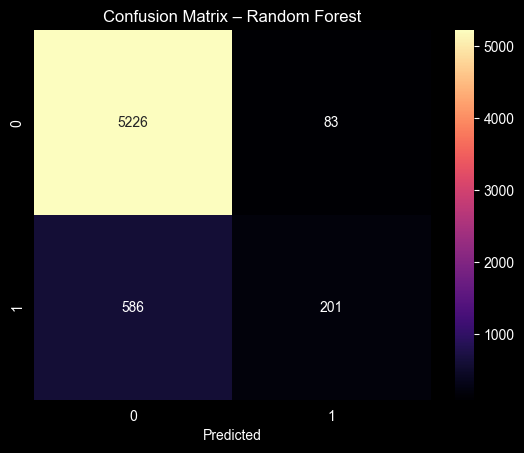

In [38]:
from sklearn.metrics import confusion_matrix

best_clf = RandomForestClassifier(max_depth= 10, min_samples_leaf= 2, min_samples_split= 2, n_estimators= 200)
best_clf.fit(X_train_scaled, y_train)
y_pred_best = best_clf.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.title('Confusion Matrix – Random Forest')
plt.show()